In [1]:
from data_analysis import Analyzer, DataPreprocessor
import pandas as pd

## Analyse du jeu de données - pas de preprocessing

In [2]:
df = pd.read_csv("RH_dataset.csv", sep=';', encoding='utf-8-sig')
analysis_RH_raw=Analyzer(df)

Dataset ready: 23857 rows and 14 columns.


In [3]:
analysis_RH_raw.df.columns

Index(['Famille d'emploi', 'Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Niveau hiérarchique', 'Salaire (Euros)', 'Statut marital', 'Véhicule',
       'matricule', 'label'],
      dtype='str')

In [4]:
analysis_RH_raw.get_inventory()

,Column,Type,Cardinality,Missing,Range/Examples
0,Famille d'emploi,str,8,0,"[Production, Commercial/Business, Etudes & Tec..."
1,Dernière promotion (mois),float64,7670,0,N/A (Numeric)
2,Dernière augmentation (mois),float64,2934,0,N/A (Numeric)
3,Début de contrat (années),float64,2433,0,N/A (Numeric)
4,Ancienneté groupe (années),float64,3660,0,N/A (Numeric)
5,Etablissement,int64,35,0,N/A (Numeric)
6,Âge (années),int64,74,0,N/A (Numeric)
7,Parent,int64,2,0,N/A (Numeric)
8,Niveau hiérarchique,int64,4,0,N/A (Numeric)
9,Salaire (Euros),int64,4901,0,N/A (Numeric)


On plote les distributions sur toutes les colonnes numériques.

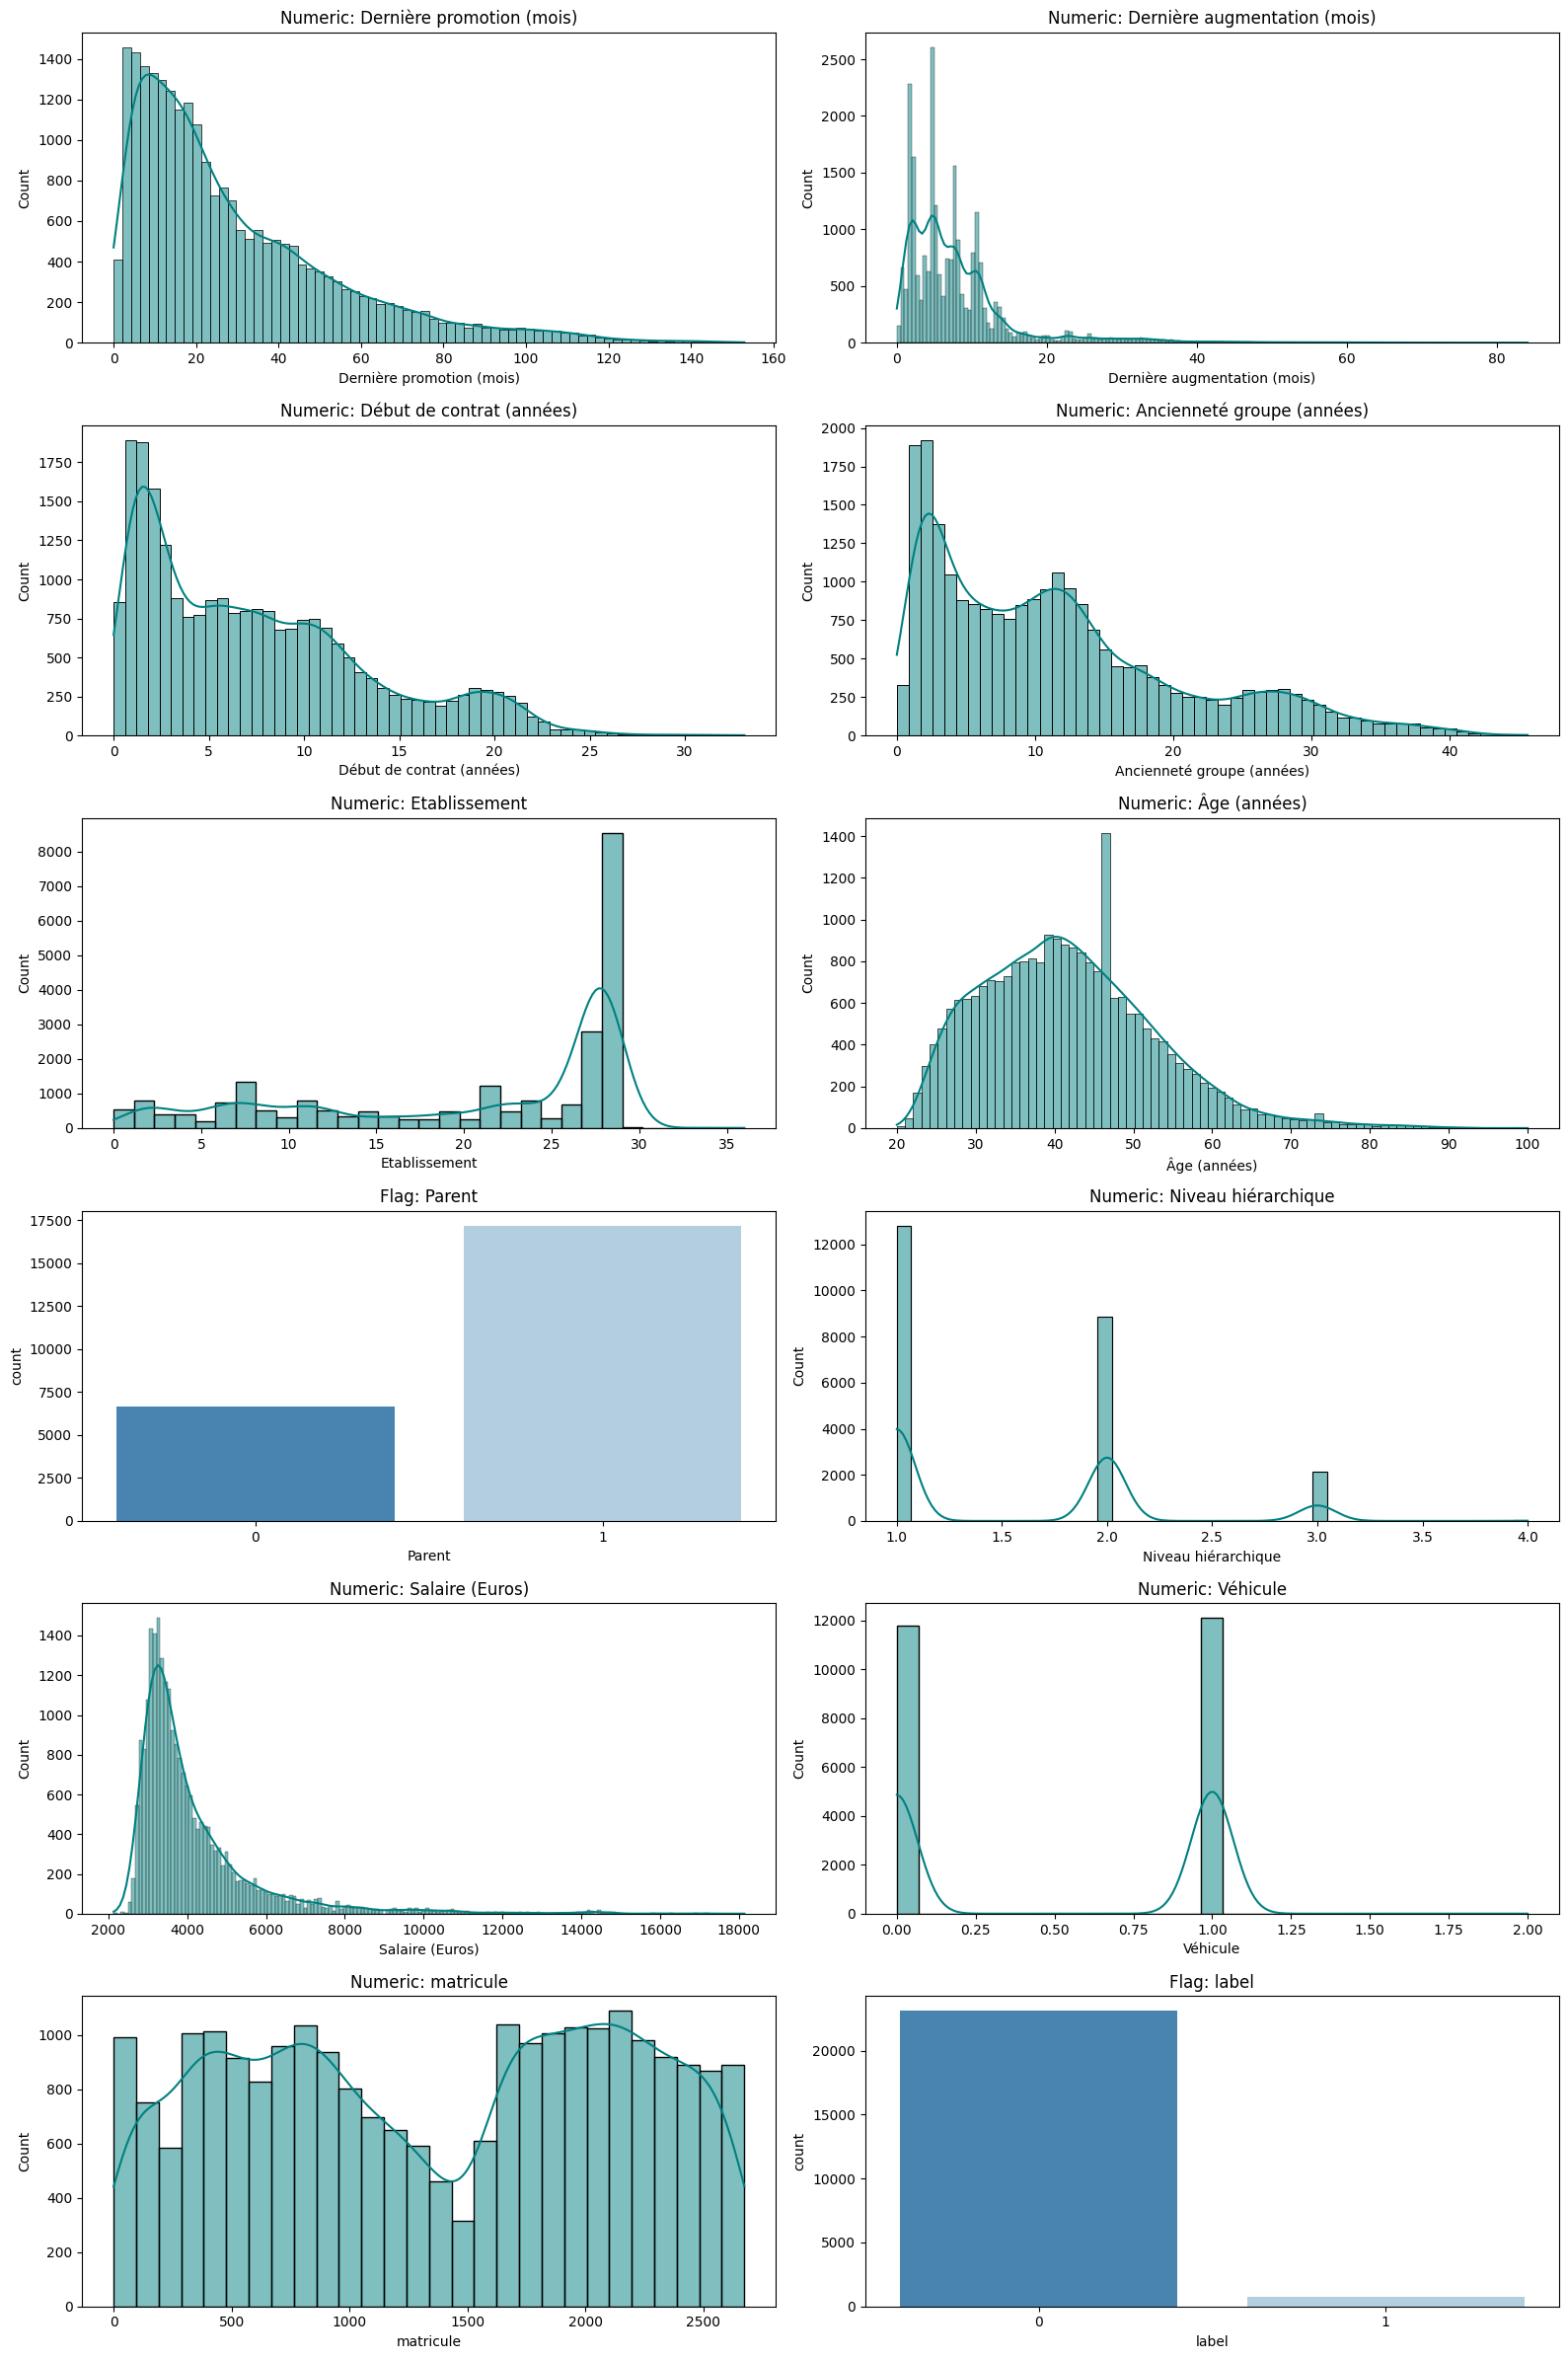

In [5]:
analysis_RH_raw.plot_distributions(['Dernière promotion (mois)',
       'Dernière augmentation (mois)', 'Début de contrat (années)',
       'Ancienneté groupe (années)', 'Etablissement', 'Âge (années)', 'Parent',
       'Niveau hiérarchique', 'Salaire (Euros)', 'Véhicule',
       'matricule', 'label'])

## Preprocessing sur les colonnes catégorielles

In [6]:
processed=DataPreprocessor(df).handle_encoding()

Encoding columns: ["Famille d'emploi", 'Statut marital']
Encoding complete. New shape: (23857, 29)


## Analyse du jeu de données - après preprocessing des colonnes catégorielles

In [7]:
analysis_RH=Analyzer(processed)
analysis_RH.df.columns

Dataset ready: 23857 rows and 29 columns.


Index(['Dernière_promotion_mois', 'Dernière_augmentation_mois',
       'Début_de_contrat_années', 'Ancienneté_groupe_années', 'Etablissement',
       'Âge_années', 'Parent', 'Niveau_hiérarchique', 'Salaire_Euros',
       'Véhicule', 'matricule', 'label', 'Famille_demploi_Commercial_Business',
       'Famille_demploi_Développement_Immobilier',
       'Famille_demploi_Etudes_&_Technique', 'Famille_demploi_IT',
       'Famille_demploi_Management', 'Famille_demploi_Matériel_Equipement',
       'Famille_demploi_Production', 'Famille_demploi_Support',
       'Statut_marital_Concubin', 'Statut_marital_Célibataire',
       'Statut_marital_Divorcée', 'Statut_marital_Mariée',
       'Statut_marital_PACS', 'Statut_marital_Séparée',
       'Statut_marital_Union_libre', 'Statut_marital_Veufve',
       'Statut_marital_ex_PACS'],
      dtype='str')

In [8]:
analysis_RH.get_inventory()

,Column,Type,Cardinality,Missing,Range/Examples
0,Dernière_promotion_mois,float64,7670,0,N/A (Numeric)
1,Dernière_augmentation_mois,float64,2934,0,N/A (Numeric)
2,Début_de_contrat_années,float64,2433,0,N/A (Numeric)
3,Ancienneté_groupe_années,float64,3660,0,N/A (Numeric)
4,Etablissement,int64,35,0,N/A (Numeric)
5,Âge_années,int64,74,0,N/A (Numeric)
6,Parent,int64,2,0,N/A (Numeric)
7,Niveau_hiérarchique,int64,4,0,N/A (Numeric)
8,Salaire_Euros,int64,4901,0,N/A (Numeric)
9,Véhicule,int64,3,0,N/A (Numeric)


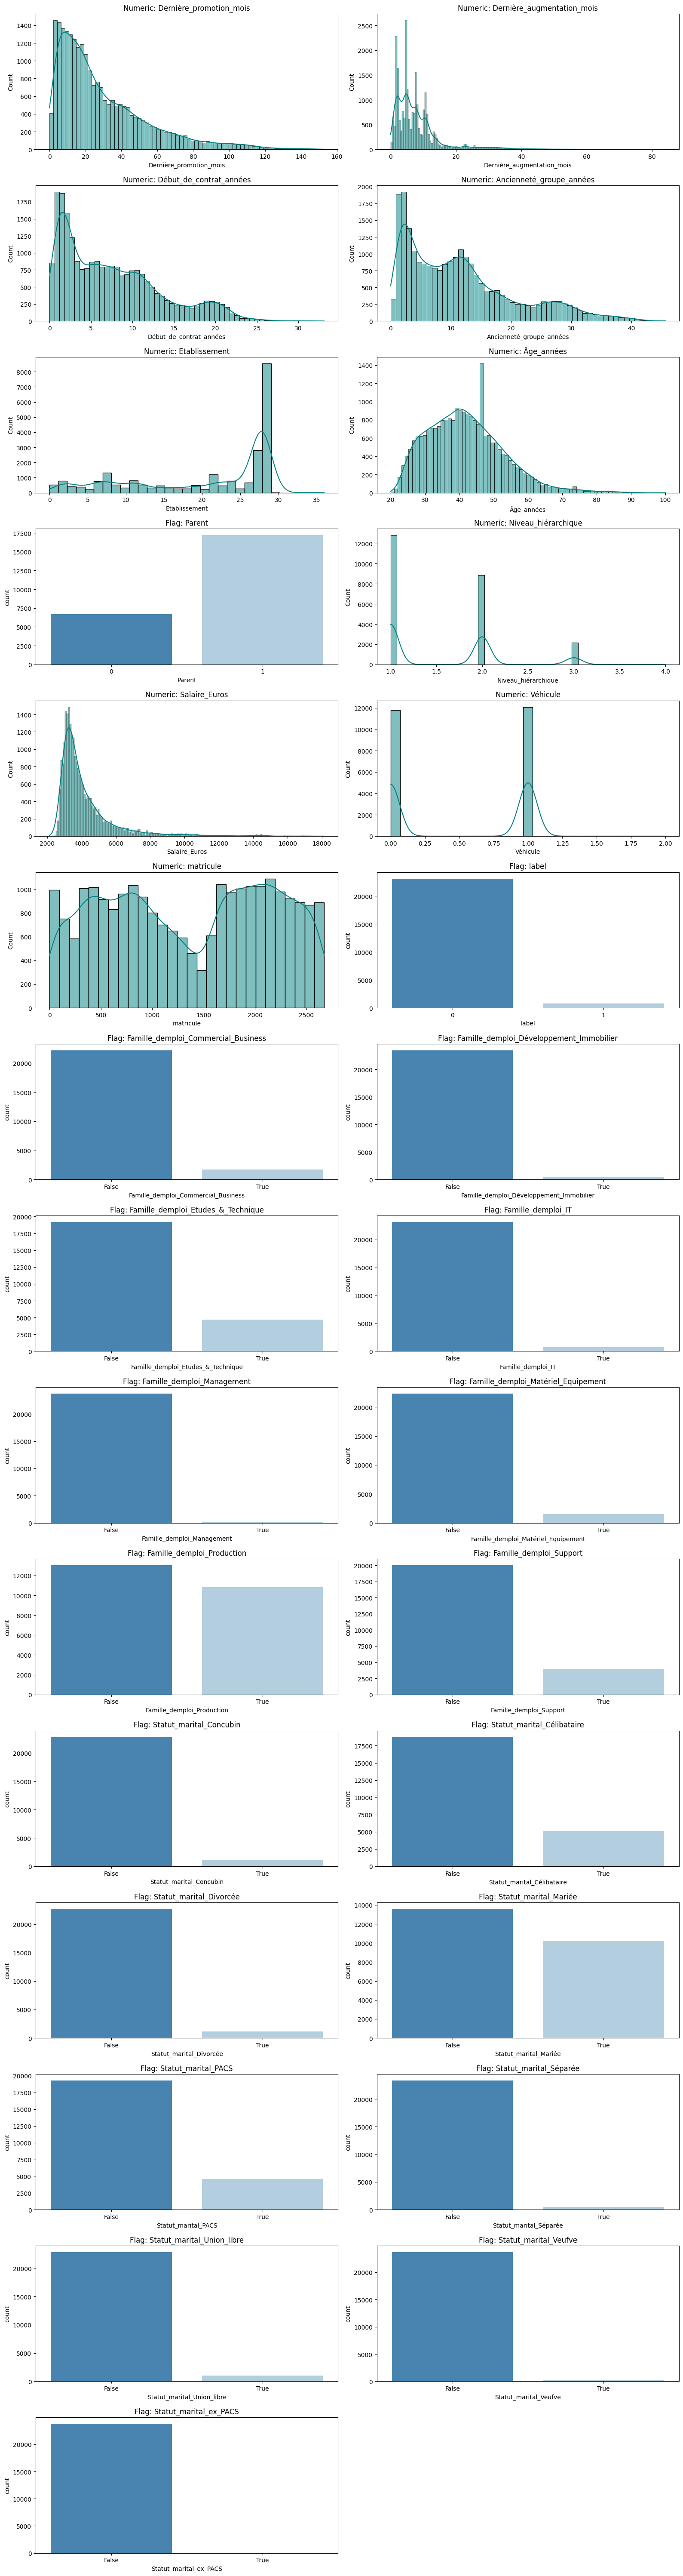

In [9]:
analysis_RH.plot_distributions(['Dernière_promotion_mois', 'Dernière_augmentation_mois',
       'Début_de_contrat_années', 'Ancienneté_groupe_années', 'Etablissement',
       'Âge_années', 'Parent', 'Niveau_hiérarchique', 'Salaire_Euros',
       'Véhicule', 'matricule', 'label', 'Famille_demploi_Commercial_Business',
       'Famille_demploi_Développement_Immobilier',
       'Famille_demploi_Etudes_&_Technique', 'Famille_demploi_IT',
       'Famille_demploi_Management', 'Famille_demploi_Matériel_Equipement',
       'Famille_demploi_Production', 'Famille_demploi_Support',
       'Statut_marital_Concubin', 'Statut_marital_Célibataire',
       'Statut_marital_Divorcée', 'Statut_marital_Mariée',
       'Statut_marital_PACS', 'Statut_marital_Séparée',
       'Statut_marital_Union_libre', 'Statut_marital_Veufve',
       'Statut_marital_ex_PACS'])

La matrice de corrélation est calculée sur l'ensemble des variables numériques et booléennes. Seules les variables présentant au moins une corrélation dont la valeur absolue dépasse **0.3** avec une autre variable sont conservées.

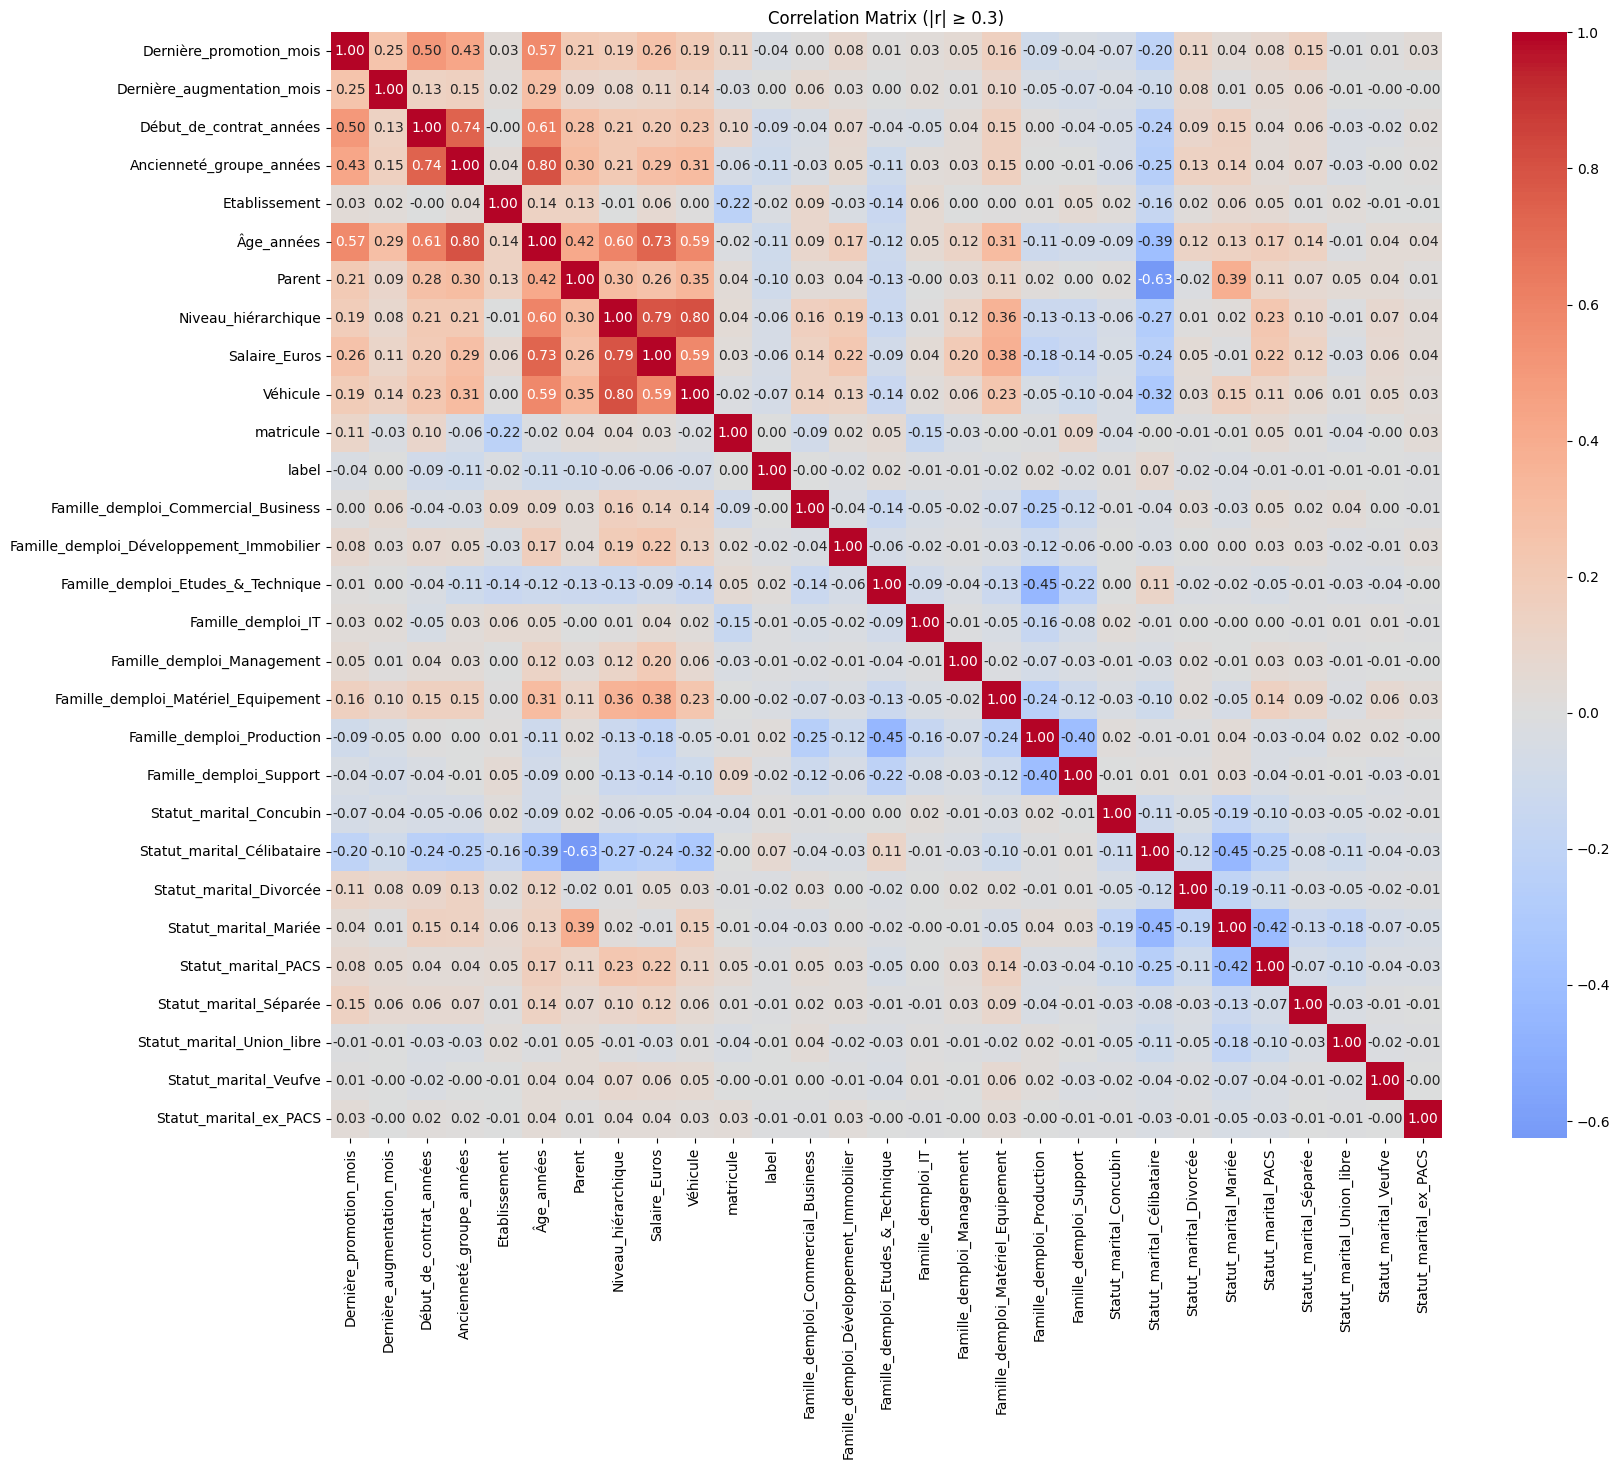

In [10]:
analysis_RH.plot_matrix_correlation(threshold=0.3)

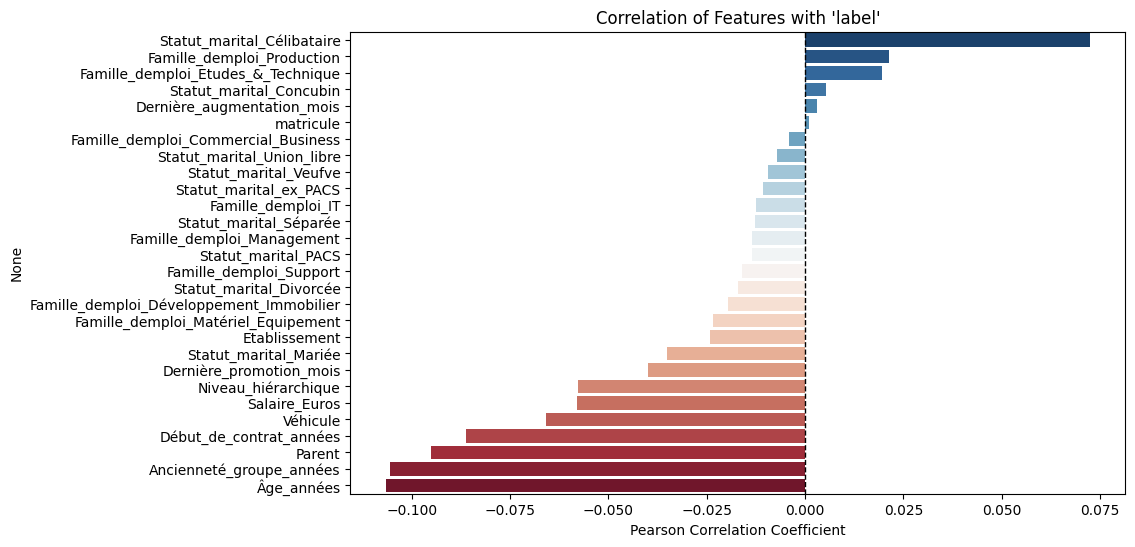

Statut_marital_Célibataire                  0.072513
Famille_demploi_Production                  0.021242
Famille_demploi_Etudes_&_Technique          0.019479
Statut_marital_Concubin                     0.005451
Dernière_augmentation_mois                  0.003011
matricule                                   0.001034
Famille_demploi_Commercial_Business        -0.003957
Statut_marital_Union_libre                 -0.007057
Statut_marital_Veufve                      -0.009308
Statut_marital_ex_PACS                     -0.010682
Famille_demploi_IT                         -0.012404
Statut_marital_Séparée                     -0.012591
Famille_demploi_Management                 -0.013484
Statut_marital_PACS                        -0.013513
Famille_demploi_Support                    -0.016009
Statut_marital_Divorcée                    -0.016953
Famille_demploi_Développement_Immobilier   -0.019704
Famille_demploi_Matériel_Equipement        -0.023319
Etablissement                              -0.

In [11]:
analysis_RH.target_correlation('label')

### Analyse correlation matrix and correlation features
Ceux qui démissionnent plus : 
- les célibataires (value = +0.075)
- les employés en production (value = +0.025)
- les employés technique (value = +0.015)
- légèrment, ceux qui ont été peu augmenté recemment (value = +0.008)

Variable de retention : 
- les séniors restent plus ( démission =  générationnel ?) en âge, séniorité, ancienneté
- salaire élevé (mais correlé à ancienneté etc)
- hiérarchie (pareil)
- véhicule (pareil)
- avoir des enfants
- marié (correlation entre enfant + mariage)

MAIS toutes les corrélations sont très faibles < |0.12|, donc, aucune variable ne prédit clairement la démission ! (phénomène multifactoriel ?)

## Analyse d'un parcours d’un employé ayant démissionné VS employé n'ayant pas démissionné

In [12]:
n_demission = df[df['label'] == 0].iloc[0] # employé n'ayant pas démisionné au cours des 6 prochains mois

demission = df[df['label'] == 1].iloc[0] # employé ayant démisionné au cours des 6 prochains mois

Comparaison deux à deux des caractéristiques des individus pour chacune des caractéristiques.

In [13]:
difference = {}
for col in df.columns:
    if n_demission[col] != demission[col]:
        difference[col] = (n_demission[col], demission[col])

for col, values in difference.items():
    if pd.api.types.is_numeric_dtype(df[col]):
        diff=(values[0] - values[1])
        print(f"{col}, différence : {diff}")
    else:
        print(f"{col}, n_demission : {values[0]}, demission : {values[1]}")

print("\n Si la différence est positive, n_demission a une valeur plus élevée que demission et vice versa.")

Dernière promotion (mois), différence : 3.270000457763672
Dernière augmentation (mois), différence : 2.8000001907348633
Début de contrat (années), différence : -0.10999995470047008
Ancienneté groupe (années), différence : -0.7799999713897704
Âge (années), différence : 6
Parent, différence : 1
Salaire (Euros), différence : 558
Statut marital, n_demission : Marié(e), demission : Célibataire
matricule, différence : -2587
label, différence : -1

 Si la différence est positive, n_demission a une valeur plus élevée que demission et vice versa.


Malgré une promotion plus récente (+3,3 mois) et une dernière augmentation plus récente (+2,8 mois), c'est l'employé ayant démissionné qui a bénéficié de ces avantages en dernier. Cela suggère que ni la reconnaissance salariale ni l'évolution de carrière récente n'ont suffi à le retenir.

L'ancienneté groupe légèrement inférieure (-0,78 ans) de l'employé démissionnaire indique que l'attachement à la structure n'est pas non plus le facteur déterminant ici.

Dans cette comparaison, les facteurs les plus discriminants semblent être l'âge (+6 ans en faveur du non-démissionnaire), le statut marital (marié vs célibataire) et le fait d'être parent. Ces trois variables sont souvent liées : les responsabilités familiales tendent à renforcer le besoin de stabilité professionnelle, ce qui pourrait expliquer une plus grande rétention. La différence salariale (+558 €) va dans le même sens mais reste modérée.

**A rediscuter !!** 

- La quasi-absence de différence sur le début de contrat (-0,11 an, soit ~1 mois) alors que la dernière promotion diffère de 3,3 mois soulève une question de définition : une promotion entraîne-t-elle systématiquement un nouveau contrat dans ce contexte ? Si oui, ces deux colonnes devraient être davantage corrélées.

- Le numéro associé à la colonne établissement vise-t-il à identifier les différentes entités juridiques du groupe étudié ? 

## Analyse des variables sensibles et biais potentiels

Dans le cadre du RGPD et du Code du travail français, certaines variables sont considérées comme sensibles car elles exposent à un risque de discrimination ou d'atteinte à la vie privée.

### Variables directement sensibles

| Variable | Motif |
|---|---|
| `matricule` | Identifiant direct de l'individu |
| `Âge (années)` | Caractéristique protégée (discrimination) |
| `Statut marital` | Donnée relevant de la vie privée |
| `Parent` | Vecteur fréquent de discrimination à l'emploi |
| `Salaire (Euros)` | Donnée confidentielle ; discriminante si croisée |

### Variables à risque indirect (proxys potentiels)

| Variable | Biais potentiel |
|---|---|
| `Famille d'emploi` | Souvent corrélée au genre |
| `Niveau hiérarchique` | Proxy possible du genre ou de l'âge |
| `Ancienneté groupe` | Pénalise les interruptions de carrière (congés parentaux) |
| `Établissement` | Peut refléter une répartition corrélée à l'origine ou au niveau de vie |
| `Véhicule` | Indicateur indirect du niveau de vie |

Conclusion : le matricule doit être exclu de toute analyse : en tant qu'identifiant direct, il ne présente aucune valeur prédictive et expose inutilement à un risque de réidentification.

Pour les variables restantes, on suppose que les données ont préalablement fait l'objet d'un traitement d'anonymisation — perturbation des âges, généralisation des salaires, suppression ou codage des variables les plus exposées. Cette hypothèse permet de manipuler le jeu de données dans son état actuel, sans transformation supplémentaire. Elle n'exonère pas pour autant d'une vigilance sur les variables à risque indirect, dont le potentiel discriminatoire peut persister après anonymisation, notamment par croisement.